In [11]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
import xgboost as xgb


In [12]:
# Load data
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [13]:
# Check for missing values in the dataset
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [14]:
# Preprocess data
df.dropna(inplace=True)
df = pd.get_dummies(df, drop_first=True)

X = df.drop('Attrition_Yes', axis=1)
y = df['Attrition_Yes']
df.head()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1102,1,2,1,1,2,94,3,2,...,False,False,False,False,False,True,False,False,True,True
1,49,279,8,1,1,2,3,61,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1373,2,2,1,4,4,92,2,1,...,True,False,False,False,False,False,False,False,True,True
3,33,1392,3,4,1,5,4,56,3,1,...,False,False,False,False,True,False,False,True,False,True
4,27,591,2,1,1,7,1,40,3,1,...,True,False,False,False,False,False,False,True,False,False


In [15]:
# Train-test split and SMOTE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)


In [16]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

🧠 Logistic Regression Accuracy: 0.8878
              precision    recall  f1-score   support

       False       0.93      0.94      0.94       255
        True       0.58      0.56      0.57        39

    accuracy                           0.89       294
   macro avg       0.76      0.75      0.75       294
weighted avg       0.89      0.89      0.89       294

--------------------------------------------------
🧠 Random Forest Accuracy: 0.8810
              precision    recall  f1-score   support

       False       0.90      0.96      0.93       255
        True       0.59      0.33      0.43        39

    accuracy                           0.88       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.86      0.88      0.87       294

--------------------------------------------------
🧠 Gradient Boosting Accuracy: 0.8673
              precision    recall  f1-score   support

       False       0.92      0.93      0.92       255
        True       0.50   

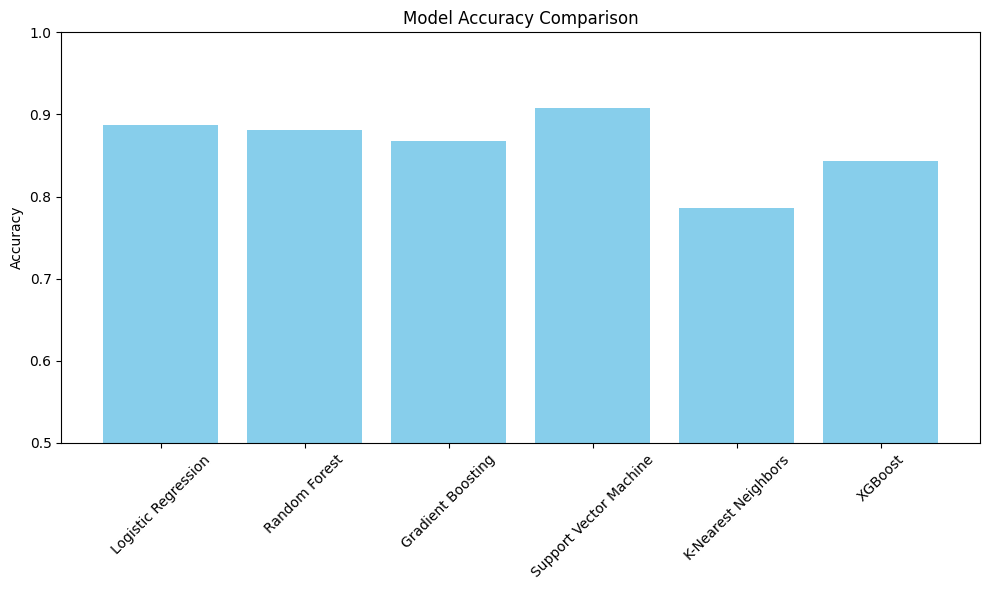

In [17]:
# Model comparison
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Support Vector Machine": SVC(probability=True, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "XGBoost": xgb.XGBClassifier(random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train_smote)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    print(f"\U0001f9e0 {name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))
    print("-" * 50)
    results.append((name, acc))

model_names = [name for name, _ in results]
accuracies = [acc for _, acc in results]

plt.figure(figsize=(10, 6))
plt.bar(model_names, accuracies, color='skyblue')
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0.5, 1.0)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
# Hyperparameter tuning for Random Forest
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', 'balanced_subsample']
}

rf_model = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid,
                           cv=3, n_jobs=-1, verbose=2, scoring='roc_auc')
grid_search.fit(X_train_scaled, y_train_smote)

print(f"Best Parameters: {grid_search.best_params_}")
best_rf_model = grid_search.best_estimator_

Fitting 3 folds for each of 540 candidates, totalling 1620 fits
Best Parameters: {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


In [19]:
# Evaluate tuned Random Forest
y_pred = best_rf_model.predict(X_test_scaled)
print(f"Tuned Random Forest Classification Report:\n{classification_report(y_test, y_pred)}")
print(f"Tuned Random Forest Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")

cv_scores = cross_val_score(best_rf_model, X_train_scaled, y_train_smote, cv=5, scoring='roc_auc')
print(f"Cross-validation AUC scores: {cv_scores}")
print(f"Mean AUC score: {cv_scores.mean():.4f}")

Tuned Random Forest Classification Report:
              precision    recall  f1-score   support

       False       0.91      0.96      0.94       255
        True       0.62      0.38      0.48        39

    accuracy                           0.89       294
   macro avg       0.77      0.67      0.71       294
weighted avg       0.87      0.89      0.88       294

Tuned Random Forest Confusion Matrix:
[[246   9]
 [ 24  15]]
Cross-validation AUC scores: [0.89441899 0.99759288 0.99478022 0.99183673 0.99620617]
Mean AUC score: 0.9750


C:\Users\user\AppData\Local\Temp\ipykernel_7812\433311576.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features['importance'], y=top_features.index, palette='viridis')


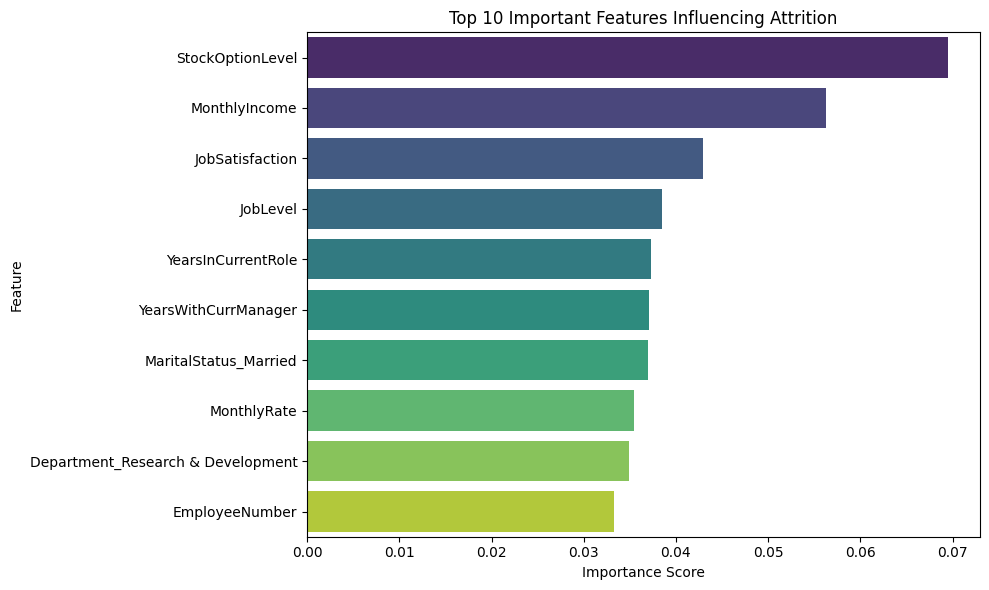

In [20]:
# Feature importance
feature_importances = pd.DataFrame(best_rf_model.feature_importances_,
                                   index=X.columns,
                                   columns=['importance']).sort_values('importance', ascending=False)
top_features = feature_importances.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_features['importance'], y=top_features.index, palette='viridis')
plt.title('Top 10 Important Features Influencing Attrition')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

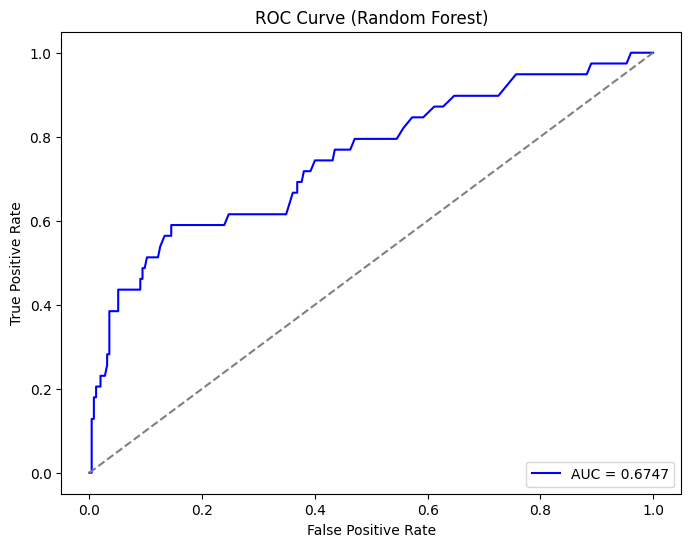

In [21]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, best_rf_model.predict_proba(X_test_scaled)[:, 1])
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc_score(y_test, y_pred):.4f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve (Random Forest)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()